``AAPredPlot().eval(df_eval, kind=...)`` visualizes model / feature-set evaluation. ``kind='eval'`` compares models across metrics from :meth:`AAPred.eval`; ``kind='comparison'`` draws a grouped benchmark barplot from a tidy frame (see [Breimann25]_):

**``eval`` = model / feature-set comparison** (not per-protein prediction). Pick the ``kind``:

- ``'eval'`` — grouped **bars, hue = model** (compare methods across metrics).
- ``'comparison'`` — grouped benchmark bars (method × condition) with a chance line.

For comparing CPP **parameter ranges** (not models), use the optimization protocol ``aap.find_features`` + ``aap.plot_eval`` instead.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import aaanalysis as aa
aa.options["verbose"] = False  # Disable verbosity
aa.plot_settings()

# DOM_GSEC example dataset + its feature set (see [Breimann25]_)
df_seq = aa.load_dataset(name="DOM_GSEC")
labels = df_seq["label"].to_list()
df_feat = aa.load_features(name="DOM_GSEC").head(20)
sf = aa.SequenceFeature()
X = sf.feature_matrix(features=df_feat, df_parts=sf.get_df_parts(df_seq=df_seq))

# Evaluate two models across metrics
aapred = aa.AAPred(models=["svm", "rf"], random_state=42)
df_eval = aapred.eval(X, labels)
aapred_plot = aa.AAPredPlot()
aa.display_df(df_eval, n_rows=10, show_shape=True)

/Users/stephanbreimann/Programming/1Packages/aaanalysis/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/stephanbreimann/Programming/1Packages/aaanalysis/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/stephanbreimann/Programming/1Packages/aaanalysis/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/stephanbreimann/Programm

DataFrame shape: (8, 5)


,model,metric,principle,score,score_std
1,SVC,accuracy,cv,0.848923,0.092943
2,SVC,balanced_accuracy,cv,0.849359,0.092783
3,SVC,f1,cv,0.854063,0.089412
4,SVC,roc_auc,cv,0.907199,0.073961
5,RandomForestClassifier,accuracy,cv,0.809231,0.064659
6,RandomForestClassifier,balanced_accuracy,cv,0.810256,0.065416
7,RandomForestClassifier,f1,cv,0.810256,0.059252
8,RandomForestClassifier,roc_auc,cv,0.887278,0.071059


**``kind='eval'``** (default) draws a grouped bar plot comparing the models across metrics (hue = model), with ``score_std`` error bars. ``baseline`` adds a chance line, ``dict_color`` sets the per-model hue, and ``ylabel`` / ``figsize`` style the axes:

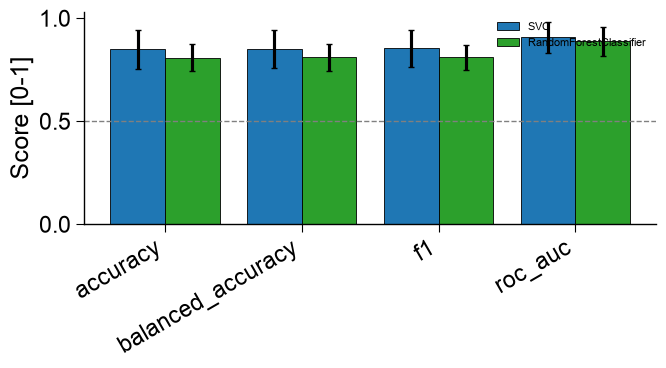

In [2]:
model_names = df_eval["model"].unique()
aapred_plot.eval(df_eval, kind="eval", baseline=0.5, ylabel="Score [0-1]", figsize=(7, 4),
                 dict_color={model_names[0]: "tab:blue", model_names[1]: "tab:green"})
plt.tight_layout()
plt.show()

**``kind='comparison'``** draws a benchmark barplot from a tidy frame: each ``condition`` is an x-axis cluster and each ``group`` a colored bar. Here a scale-based baseline is compared against CPP features on two classes:

In [3]:
df_bench = pd.DataFrame({
    "group":     ["Scale-based", "Scale-based", "CPP", "CPP"],
    "condition": ["Substrate", "Non-substrate", "Substrate", "Non-substrate"],
    "value":     [61.0, 60.0, 71.0, 74.0],
})
aa.display_df(df_bench, n_rows=10, show_shape=True)

DataFrame shape: (4, 3)


,group,condition,value
1,Scale-based,Substrate,61.000000
2,Scale-based,Non-substrate,60.000000
3,CPP,Substrate,71.000000
4,CPP,Non-substrate,74.000000


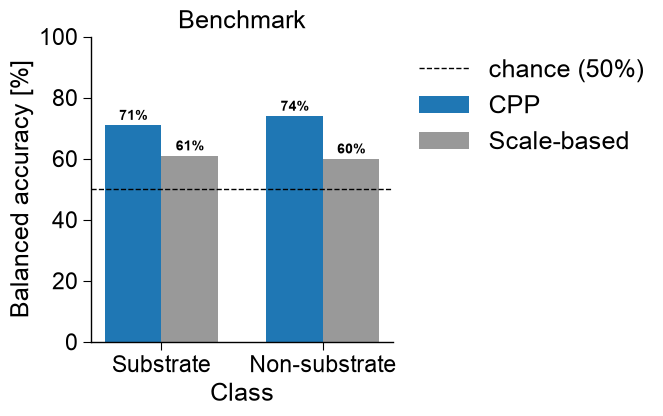

In [4]:
aapred_plot.eval(
    df_bench, kind="comparison", group="group", condition="condition", value="value",
    baseline=50, baseline_label="chance (50%)", annotate=True, annotation_fmt="{:.0f}%",
    group_order=["CPP", "Scale-based"], condition_order=["Substrate", "Non-substrate"],
    colors={"CPP": "tab:blue", "Scale-based": "0.6"}, bar_width=0.7, figsize=(7, 4.5),
    xlabel="Class", ylabel="Balanced accuracy [%]", title="Benchmark",
    ylim=(0, 100), fontsize_annotations=10, xtick_rotation=0)
plt.tight_layout()
plt.show()